In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU is available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU not available, using CPU")


Device: cuda
GPU is available
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
# Memory-safe loading
X = np.load("X_train.npy")
Y = np.load("Y_train.npy")

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)

Images shape: (3986, 16, 128, 128)
Masks shape: (3986, 16, 128, 128)


In [4]:
import numpy as np

def augment_patch(image, mask):

    # Random flip (left-right)
    if np.random.rand() > 0.5:
        image = np.flip(image, axis=2)
        mask = np.flip(mask, axis=2)

    # Random flip (up-down)
    if np.random.rand() > 0.5:
        image = np.flip(image, axis=1)
        mask = np.flip(mask, axis=1)

    # Random rotation
    if np.random.rand() > 0.5:
        k = np.random.randint(0,4)
        image = np.rot90(image, k, axes=(1,2))
        mask = np.rot90(mask, k, axes=(1,2))

    # Intensity scaling
    if np.random.rand() > 0.5:
        scale = np.random.uniform(0.9,1.1)
        image = image * scale

    # Gaussian noise
    if np.random.rand() > 0.5:
        noise = np.random.normal(0,0.02,image.shape)
        image = image + noise

    # Gamma augmentation (safe)
    if np.random.rand() > 0.5:

        img_min = image.min()
        img_max = image.max()

        image = (image - img_min) / (img_max - img_min + 1e-8)

        gamma = np.random.uniform(0.8,1.2)
        image = image ** gamma

    image = np.clip(image, -5, 5)

    return image, mask

In [5]:
from torch.utils.data import Dataset
class MedicalDataset(Dataset):

    def __init__(self, images, masks, augment=False):

        self.images = images
        self.masks = masks
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = self.images[idx]
        mask = self.masks[idx]

        if self.augment:
            img, mask = augment_patch(img, mask)  

        img = torch.tensor(img.copy(), dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask.copy(), dtype=torch.long)

        return img, mask

In [6]:
import numpy as np

X_train = np.load("X_train.npy", mmap_mode="r")
Y_train = np.load("Y_train.npy", mmap_mode="r")

X_val = np.load("X_val.npy", mmap_mode="r")
Y_val = np.load("Y_val.npy", mmap_mode="r")
print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (3986, 16, 128, 128)
Val: (613, 16, 128, 128)


In [7]:
train_dataset = MedicalDataset(X_train, Y_train, augment=True)

val_dataset = MedicalDataset(X_val, Y_val, augment=False)

In [8]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    num_workers=0,
    pin_memory=True
)

In [9]:
class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [10]:
class Down(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.pool = nn.MaxPool3d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        x = self.pool(x)
        return self.conv(x)

In [11]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv3d(F_g, F_int, kernel_size=1),
            nn.BatchNorm3d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv3d(F_l, F_int, kernel_size=1),
            nn.BatchNorm3d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv3d(F_int, 1, kernel_size=1),
            nn.BatchNorm3d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [12]:
class Up(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose3d(in_ch, out_ch, kernel_size=2, stride=2)

        self.att = AttentionBlock(
            F_g=out_ch,
            F_l=out_ch,
            F_int=out_ch // 2
        )

        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):

        x1 = self.up(x1)

        # attention gate
        x2 = self.att(x1, x2)

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

In [13]:
class AttentionUNet3D(nn.Module):

    def __init__(self, n_classes=3):
        super().__init__()

        self.inc = DoubleConv(1, 32)

        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)

        self.up1 = Up(256, 128)
        self.up2 = Up(128, 64)
        self.up3 = Up(64, 32)

        self.out = nn.Conv3d(32, n_classes, kernel_size=1)

    def forward(self, x):

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)

        return self.out(x)

In [14]:
def init_weights(m):
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
model = AttentionUNet3D(n_classes=3).to(device)
model.apply(init_weights)

AttentionUNet3D(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine

In [15]:
def dice_score(pred, target, num_classes=3):

    pred = torch.argmax(pred, dim=1)

    dice = []

    for cls in range(num_classes):

        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()

        score = (2*intersection + 1e-5) / \
                (pred_cls.sum() + target_cls.sum() + 1e-5)

        dice.append(score.item())

    return dice

In [16]:
def iou_score(pred, target, num_classes=3):

    pred = torch.argmax(pred, dim=1)

    iou = []

    for cls in range(num_classes):

        pred_cls = (pred == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).float().sum()
        union = (pred_cls | target_cls).float().sum()

        if union == 0:
            iou.append(0.0)   # safer than nan
        else:
            score = intersection / union
            iou.append(score.item())

    return iou

In [17]:
class DiceLoss(nn.Module):

    def __init__(self, num_classes=3):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, pred, target):

        pred = F.softmax(pred, dim=1)

        loss = 0

        for cls in range(1,self.num_classes):

            pred_cls = pred[:, cls]
            target_cls = (target == cls).float()

            intersection = (pred_cls * target_cls).sum()

            dice = (2*intersection + 1e-5) / \
                   (pred_cls.sum() + target_cls.sum() + 1e-5)

            loss += 1 - dice

        return loss/self.num_classes

In [18]:
class CombinedLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.ce = nn.CrossEntropyLoss(weight=torch.tensor([0.2, 0.3, 0.5], device=device))
        self.dice = DiceLoss()

    def forward(self, pred, target):

        ce = self.ce(pred, target)
        dice = self.dice(pred, target)

        return ce + dice

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet3D(n_classes=3).to(device)

print(model)

AttentionUNet3D(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine

In [20]:
criterion = CombinedLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5,
    verbose=True
)

c:\Users\mahaj\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
epochs = 20

best_dice = 0

for epoch in range(epochs):

    saved = ""

    # ======================
    # TRAINING
    # ======================
    model.train()

    train_loss = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred, y)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0

    dice_total = np.zeros(3)
    iou_total = np.zeros(3)

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(pred, y)

            val_loss += loss.item()

            dice = dice_score(pred, y)
            iou = iou_score(pred, y)

            dice_total += np.array(dice) * x.size(0)
            iou_total += np.array(iou) * x.size(0)

    val_loss /= len(val_loader)

    dice_avg = dice_total / len(val_dataset)
    iou_avg = iou_total / len(val_dataset)

    scheduler.step(val_loss)


    # ======================
    # BEST MODEL CHECK
    # ======================

    mean_dice = (dice_avg[1] + dice_avg[2]) / 2

    if mean_dice > best_dice:

        best_dice = mean_dice

        torch.save(model.state_dict(), "best_AttentionUnet.pth")

        saved = "✅ Model Saved"


    else:
        saved = ""


    # ======================
    # PRINT RESULTS
    # ======================

    print("\n================================================")
    print(f"Epoch [{epoch+1}/{epochs}]")
    print("================================================")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print("\nDice Scores")
    print(f"Background : {dice_avg[0]:.4f}")
    print(f"Liver      : {dice_avg[1]:.4f}")
    print(f"Tumor      : {dice_avg[2]:.4f}")

    print("\nIoU Scores")
    print(f"Background : {iou_avg[0]:.4f}")
    print(f"Liver      : {iou_avg[1]:.4f}")
    print(f"Tumor      : {iou_avg[2]:.4f}")

    print(f"\nMean Dice (Liver+Tumor): {mean_dice:.4f}")

    if saved:
        print(saved)


Epoch [1/20]
Train Loss : 1.0616
Val Loss   : 0.7802

Dice Scores
Background : 0.9447
Liver      : 0.4942
Tumor      : 0.9315

IoU Scores
Background : 0.8996
Liver      : 0.4024
Tumor      : 0.0000

Mean Dice (Liver+Tumor): 0.7129
✅ Model Saved

Epoch [2/20]
Train Loss : 0.7668
Val Loss   : 0.5817

Dice Scores
Background : 0.9714
Liver      : 0.7092
Tumor      : 0.7455

IoU Scores
Background : 0.9461
Liver      : 0.6431
Tumor      : 0.0000

Mean Dice (Liver+Tumor): 0.7273
✅ Model Saved

Epoch [3/20]
Train Loss : 0.6743
Val Loss   : 0.6219

Dice Scores
Background : 0.9675
Liver      : 0.6576
Tumor      : 0.7423

IoU Scores
Background : 0.9393
Liver      : 0.5811
Tumor      : 0.0000

Mean Dice (Liver+Tumor): 0.6999


In [21]:
best_model = AttentionUNet3D().to(device)

best_model.load_state_dict(torch.load("best_AttentionUnet.pth"))

best_model.eval()

print("Best model loaded!")

Best model loaded!


C:\Users\mahaj\AppData\Local\Temp\ipykernel_12968\2913405973.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_AttentionUnet.pt

In [22]:
dice_total = np.zeros(3)
iou_total = np.zeros(3)

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(device)
        y = y.to(device)

        pred = best_model(x)

        dice = dice_score(pred, y)
        iou = iou_score(pred, y)

        dice_total += np.array(dice)
        iou_total += np.array(iou)

dice_avg = dice_total / len(val_loader)
iou_avg = iou_total / len(val_loader)

mean_dice = (dice_avg[1] + dice_avg[2]) / 2

In [23]:
print("\n====================================")
print("FINAL BEST MODEL RESULTS")
print("====================================")

print("\nDice Scores")
print(f"Background : {dice_avg[0]:.4f}")
print(f"Liver      : {dice_avg[1]:.4f}")
print(f"Tumor      : {dice_avg[2]:.4f}")

print("\nIoU Scores")
print(f"Background : {iou_avg[0]:.4f}")
print(f"Liver      : {iou_avg[1]:.4f}")
print(f"Tumor      : {iou_avg[2]:.4f}")

print("\nMean Dice (Liver + Tumor):", round(mean_dice,4))


FINAL BEST MODEL RESULTS

Dice Scores
Background : 0.9715
Liver      : 0.7080
Tumor      : 0.7459

IoU Scores
Background : 0.9462
Liver      : 0.6420
Tumor      : 0.0000

Mean Dice (Liver + Tumor): 0.727


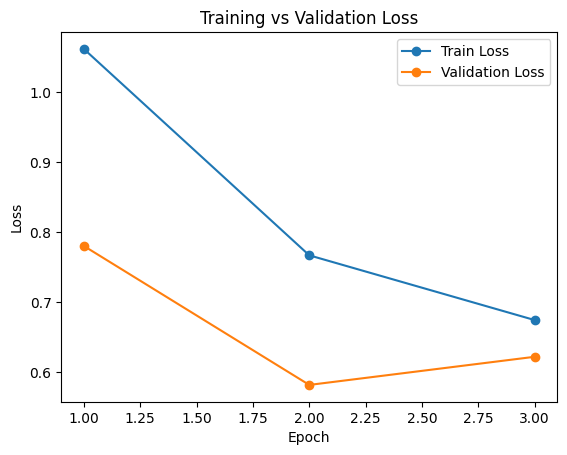

In [24]:
import matplotlib.pyplot as plt

epochs = [1,2,3]

train_loss = [1.0616, 0.7668, 0.6743]
val_loss   = [0.7802, 0.5817, 0.6219]

plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

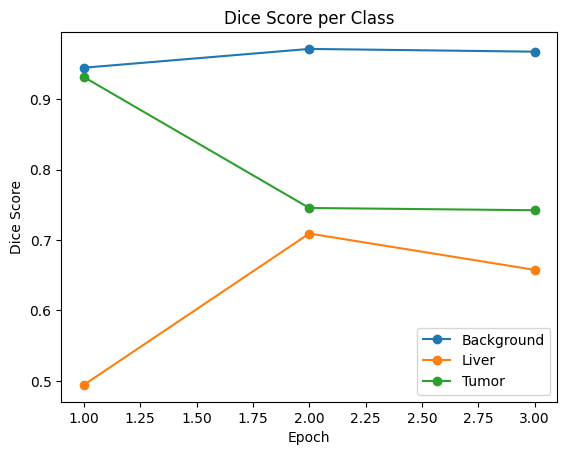

In [25]:
epochs = [1,2,3]

dice_bg    = [0.9447,0.9714,0.9675]
dice_liver = [0.4942,0.7092,0.6576]
dice_tumor = [0.9315,0.7455,0.7423]

plt.plot(epochs, dice_bg, marker='o', label="Background")
plt.plot(epochs, dice_liver, marker='o', label="Liver")
plt.plot(epochs, dice_tumor, marker='o', label="Tumor")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score per Class")
plt.legend()

plt.show()

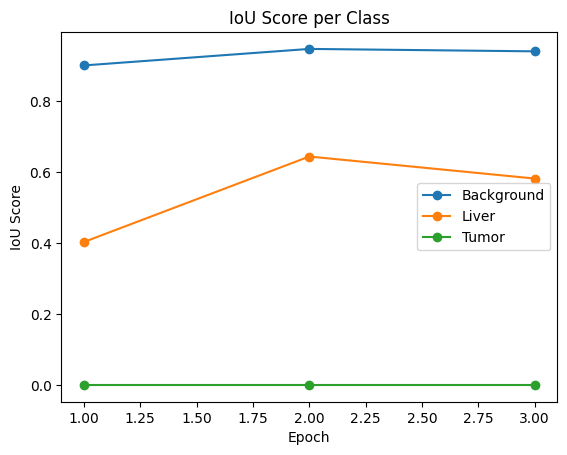

In [26]:
epochs = [1,2,3]

iou_bg    = [0.8996,0.9461,0.9393]
iou_liver = [0.4024,0.6431,0.5811]
iou_tumor = [0.0,0.0,0.0]

plt.plot(epochs, iou_bg, marker='o', label="Background")
plt.plot(epochs, iou_liver, marker='o', label="Liver")
plt.plot(epochs, iou_tumor, marker='o', label="Tumor")

plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.title("IoU Score per Class")
plt.legend()

plt.show()

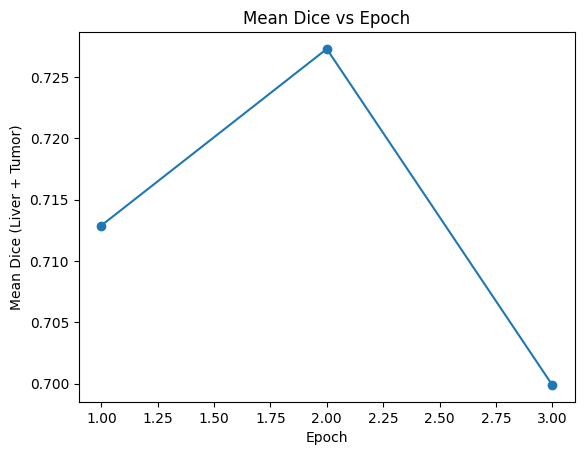

In [27]:
epochs = [1,2,3]

mean_dice = [0.7129,0.7273,0.6999]

plt.plot(epochs, mean_dice, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Mean Dice (Liver + Tumor)")
plt.title("Mean Dice vs Epoch")

plt.show()

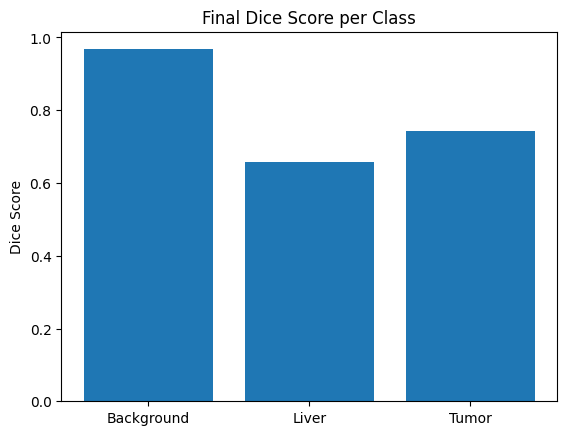

In [28]:
classes = ["Background","Liver","Tumor"]

dice_scores = [0.9675,0.6576,0.7423]

plt.bar(classes, dice_scores)

plt.ylabel("Dice Score")
plt.title("Final Dice Score per Class")

plt.show()

In [26]:
import nibabel as nib
import numpy as np

img_path = "C:\\Users\\mahaj\\Downloads\\Lits\\images\\volume-3.nii"
mask_path = "C:\\Users\\mahaj\\Downloads\\Lits\\segmentations\\segmentation-3.nii"

image = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

# convert to (D,H,W)
image = np.transpose(image,(2,0,1))
mask = np.transpose(mask,(2,0,1))

In [27]:
print(image.shape,mask.shape)

(534, 512, 512) (534, 512, 512)


In [28]:
import nibabel as nib
import numpy as np

def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def clip_hu(volume, min_hu=-200, max_hu=250):
    return np.clip(volume, min_hu, max_hu)

def normalize(volume):
    mean = np.mean(volume)
    std = np.std(volume)
    return (volume - mean) / (std + 1e-8)

def clean_mask(mask):
    return mask.astype(np.uint8)

def remove_empty_slices(volume, mask):

    v_slices = []
    m_slices = []

    # volume shape = (D, H, W)
    for i in range(volume.shape[0]):
        if np.sum(mask[i]) > 0:
            v_slices.append(volume[i])
            m_slices.append(mask[i])

    return np.array(v_slices), np.array(m_slices)

def preprocess_image(image_path, mask_path):

    image = load_nii(image_path)
    mask = load_nii(mask_path)

    # convert (H,W,D) → (D,H,W)
    image = np.transpose(image, (2, 0, 1))
    mask = np.transpose(mask, (2, 0, 1))

    image = clip_hu(image)
    image = normalize(image)
    mask = clean_mask(mask)

    image, mask = remove_empty_slices(image, mask)

    if image.ndim != 3 or image.shape[0] < 16:
        return None, None

    # return full volume instead of patches
    return image, mask


# run preprocessing
image, mask = preprocess_image(img_path, mask_path)

In [29]:
print(image.shape,mask.shape)

(169, 512, 512) (169, 512, 512)


In [30]:
def sliding_window_inference(model, volume,
                             patch_size=(16,128,128),
                             stride=(8,64,64)):

    model.eval()

    D,H,W = volume.shape
    d,h,w = patch_size

    output = np.zeros((3,D,H,W), dtype=np.float32)
    count  = np.zeros((D,H,W), dtype=np.float32)

    for z in range(0, D-d+1, stride[0]):
        for y in range(0, H-h+1, stride[1]):
            for x in range(0, W-w+1, stride[2]):

                patch = volume[z:z+d, y:y+h, x:x+w]

                patch = torch.tensor(patch).float().unsqueeze(0).unsqueeze(0).to(device)

                with torch.no_grad():
                    pred = model(patch)
                    pred = F.softmax(pred, dim=1)

                pred = pred.cpu().numpy()[0]

                output[:,z:z+d,y:y+h,x:x+w] += pred
                count[z:z+d,y:y+h,x:x+w] += 1

    output = output / np.maximum(count,1)[None,:,:,:]

    seg = np.argmax(output, axis=0)

    return seg

In [31]:
import cv2
import matplotlib.pyplot as plt

def show_overlay(img, mask, pred):

    plt.figure(figsize=(12,4))

    # CT
    plt.subplot(131)
    plt.imshow(img, cmap="gray")
    plt.title("CT")
    plt.axis("off")

    # Ground Truth boundary
    gt = img.copy()
    gt = cv2.cvtColor((gt*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

    liver = (mask==1).astype(np.uint8)
    tumor = (mask==2).astype(np.uint8)

    contours,_ = cv2.findContours(liver,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(gt,contours,-1,(0,255,0),2)

    contours,_ = cv2.findContours(tumor,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(gt,contours,-1,(255,0,0),2)

    plt.subplot(132)
    plt.imshow(gt)
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction boundary
    pr = img.copy()
    pr = cv2.cvtColor((pr*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

    liver = (pred==1).astype(np.uint8)
    tumor = (pred==2).astype(np.uint8)

    contours,_ = cv2.findContours(liver,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(pr,contours,-1,(0,255,0),2)

    contours,_ = cv2.findContours(tumor,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(pr,contours,-1,(255,0,0),2)

    plt.subplot(133)
    plt.imshow(pr)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

In [33]:
best_model = AttentionUNet3D().to(device)

best_model.load_state_dict(torch.load("best_AttentionUnet.pth"))

best_model.eval()

C:\Users\mahaj\AppData\Local\Temp\ipykernel_19444\832180776.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_AttentionUnet.pth

AttentionUNet3D(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine

In [34]:
pred_volume = sliding_window_inference(best_model, image)
print("Prediction labels:", np.unique(pred_volume))
print("Ground truth labels:", np.unique(mask))
print(image.shape,mask.shape)

Prediction labels: [0 1 2]
Ground truth labels: [0 1 2]
(169, 512, 512) (169, 512, 512)


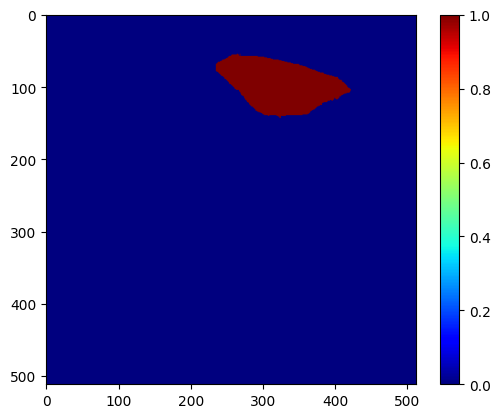

In [35]:
plt.imshow(mask[50], cmap="jet")
plt.colorbar()
plt.show()

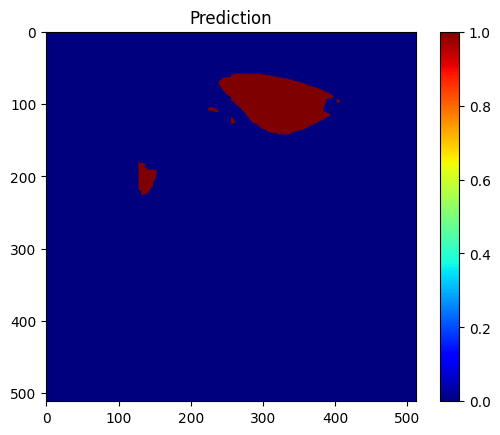

In [36]:
plt.imshow(pred_volume[50], cmap="jet")
plt.colorbar()
plt.title("Prediction")
plt.show()

In [37]:
from scipy.ndimage import label

def remove_small_regions(mask, min_size=500):

    labeled, num = label(mask)
    cleaned = np.zeros_like(mask)

    for i in range(1, num+1):
        region = labeled == i
        if region.sum() > min_size:
            cleaned[region] = 1

    return cleaned

In [38]:
liver = remove_small_regions(pred_volume == 1)
tumor = remove_small_regions(pred_volume == 2)

pred_volume = np.zeros_like(pred_volume)
pred_volume[liver == 1] = 1
pred_volume[tumor == 1] = 2

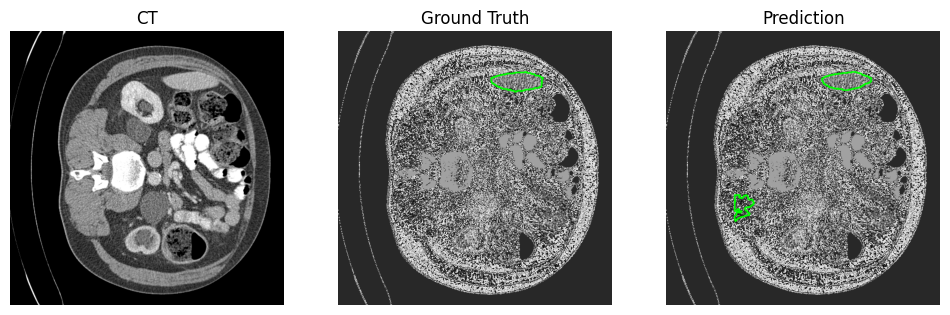

In [39]:
slice_id = np.where(mask.sum(axis=(1,2)) > 0)[0][11]

show_overlay(
    image[slice_id],
    mask[slice_id],
    pred_volume[slice_id]
)

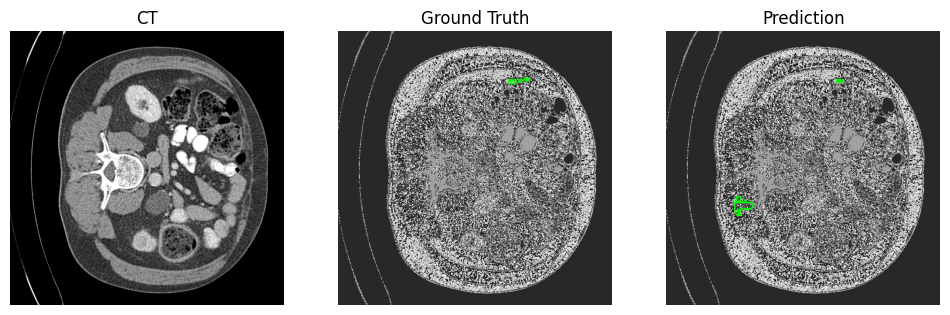

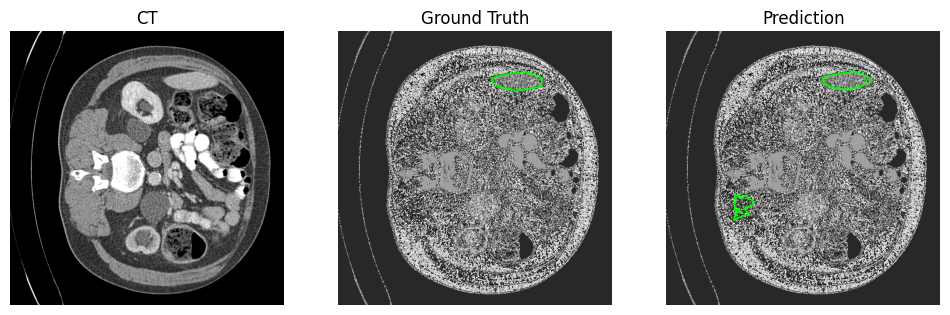

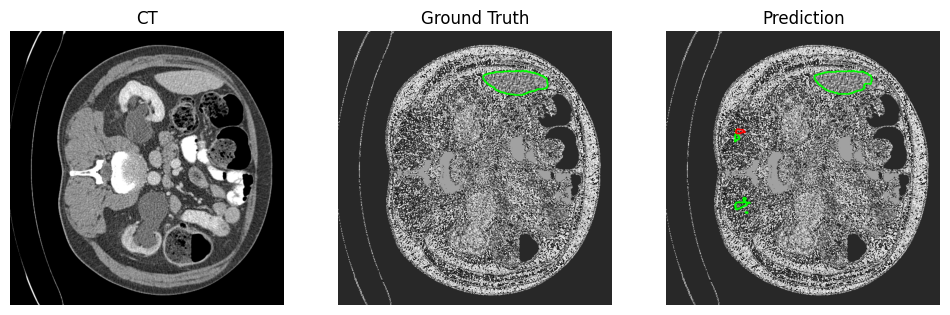

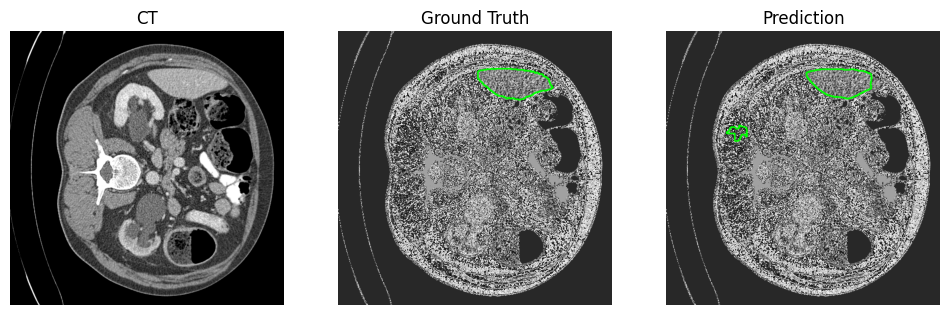

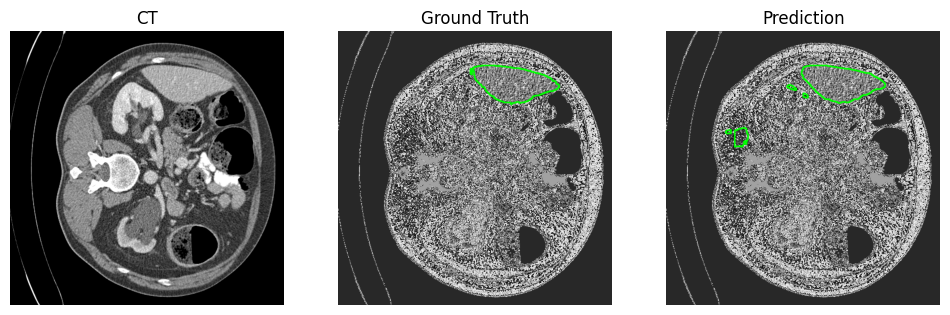

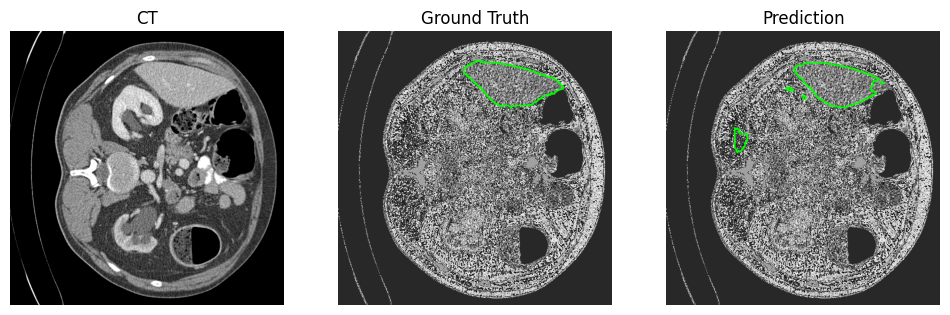

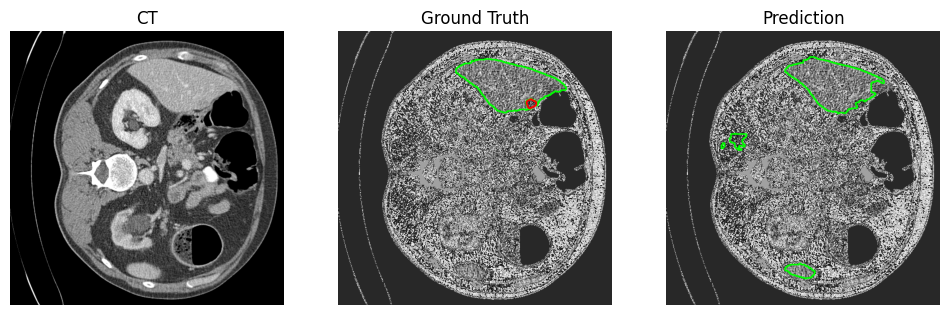

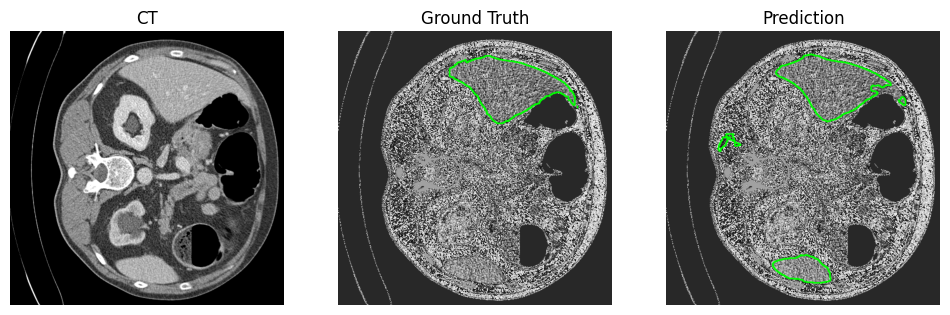

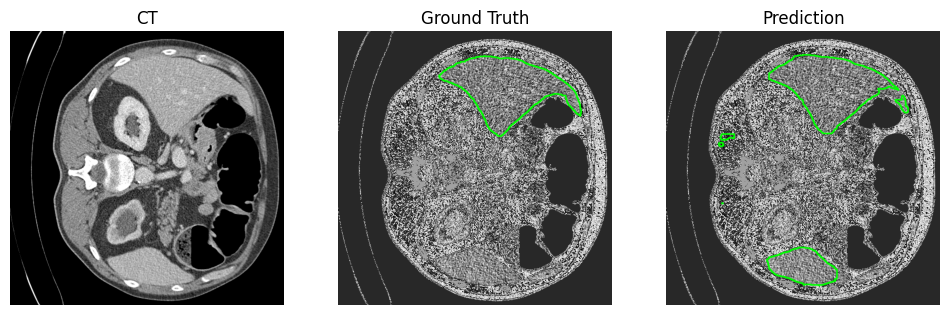

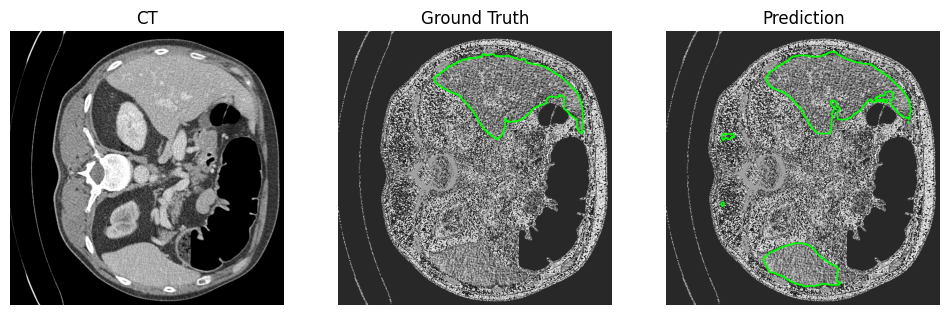

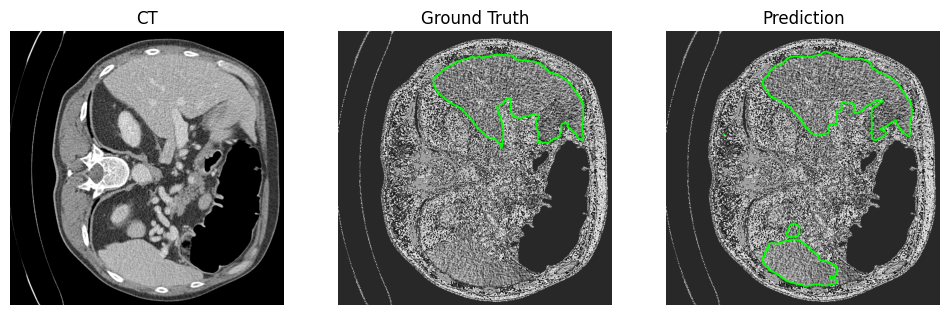

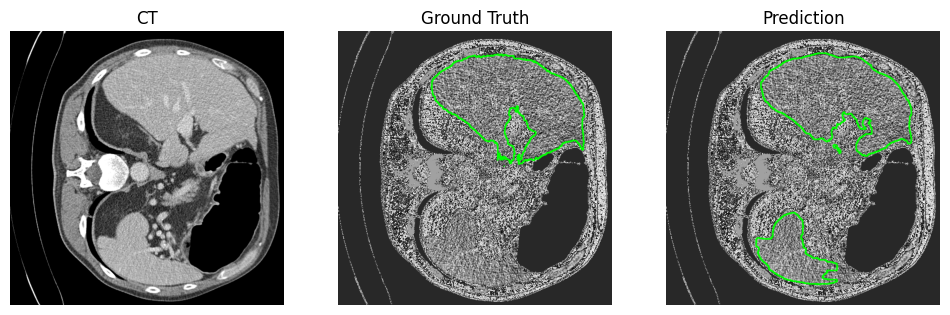

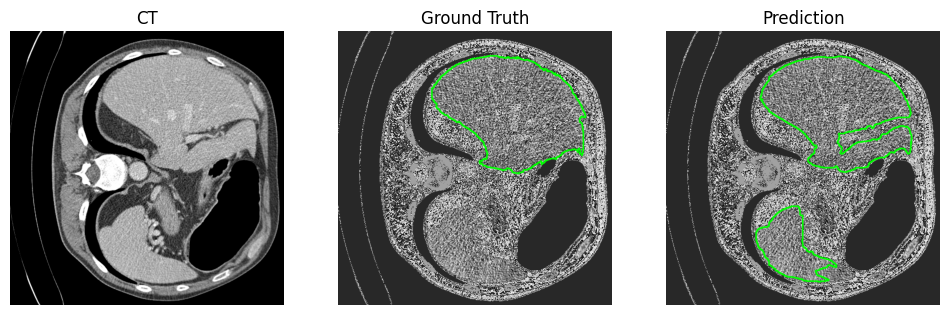

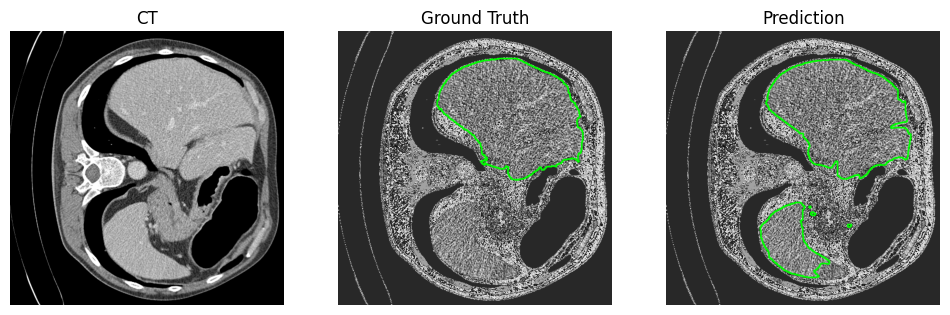

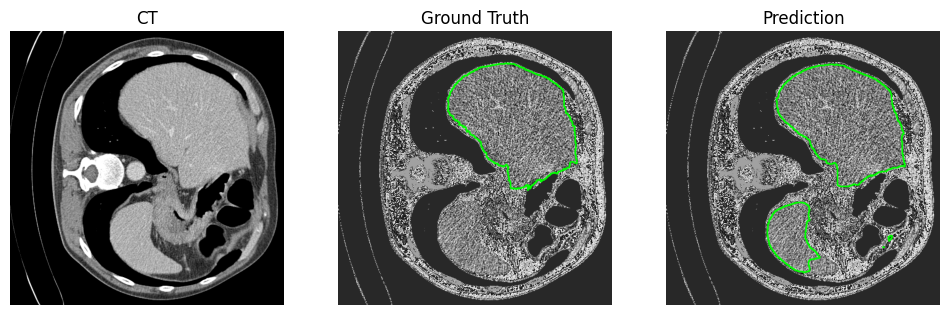

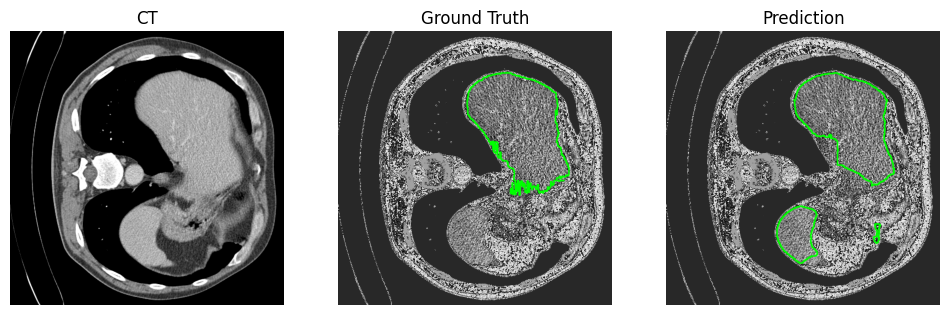

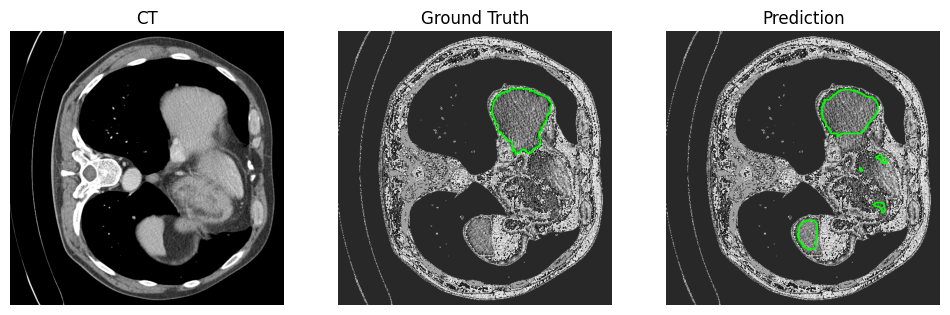

In [40]:
for s in range(0,image.shape[0],10):

    if np.sum(mask[s]) > 0:   # slice contains organ

        show_overlay(
            image[s],
            mask[s],
            pred_volume[s]
        )